In [ ]:
import seaborn as sns
import pandas as pd
import numpy as np
from pathlib import Path
from matplotlib import pyplot as plt
from matplotlib.ticker import MaxNLocator
import math
from pathlib import Path

from xarch_tokenizers.logging.report_utils import (
    load_predictions,
    load_all_samples,
    clean_model_name,
)
from xarch_tokenizers.logging.plot_utils import (
    setup_styles,
    get_new_6_fig,
    MODEL_TO_COLOR,
    get_new_fig,
)


setup_styles()
%load_ext autoreload
%autoreload 2

In [104]:
METRIC = "acc_norm"


def get_canonical_and_perturbed_df(
    samples,
    only_keep_canonical_true: bool = False,
    keep_remains_or_becomes_correct: bool = False,
    only_keep_perturbed_true: bool = False,
):
    """returns filtered out samples too"""
    if (
        (only_keep_canonical_true and keep_remains_or_becomes_correct)
        or (only_keep_canonical_true and only_keep_perturbed_true)
        or (keep_remains_or_becomes_correct and only_keep_perturbed_true)
    ):
        raise ValueError(
            f"Please pass these exclusively, only_keep_canonical_true: true for canonical, model_name true, keep_remains_or_becomes_correct: True to include the ones where the perturbed version becomes correct"
        )
    print(f"Processing {len(samples)} examples")
    samples["model_name"] = samples["model_name"].apply(clean_model_name)
    samples["is_canonical"] = (
        samples["variation_id"].apply(lambda x: str(x).split(".")[1]) == "0"
    )
    canonical_samples = samples[samples["is_canonical"]]
    perturbed_samples = samples[~samples["is_canonical"]]
    canonical_values = canonical_samples[["set_id", "model_name", METRIC]].rename(
        columns={METRIC: f"canonical_{METRIC}"}
    )

    perturbed_samples = perturbed_samples.merge(
        canonical_values, on=["set_id", "model_name"], how="left"
    )
    perturbed_samples[f"canonical-perturbed_{METRIC}"] = (
        perturbed_samples[f"canonical_{METRIC}"] - perturbed_samples[METRIC]
    )

    if only_keep_canonical_true:
        print(
            f"Cleaning samples, will be dropping entries (set_id-model pairs) where the canonical is predicted wrong."
        )
        correct_canonical_pairs = canonical_samples[canonical_samples[METRIC] == 1][
            ["set_id", "model_name"]
        ]
        print(
            f"Keeping {len(correct_canonical_pairs)} correct pairs, dropping {len(canonical_samples) - len(correct_canonical_pairs)} entries."
        )

        canonical_samples = canonical_samples[canonical_samples[METRIC] == 1]

        # Step 3: Filter perturbed_samples to keep only rows with correct canonical pairs
        # Method 1: Using merge (RECOMMENDED)
        perturbed_samples = perturbed_samples.merge(
            correct_canonical_pairs,
            on=["set_id", "model_name"],
            how="inner",  # Only keep rows that exist in both
        )
        samples = pd.concat((canonical_samples, perturbed_samples), ignore_index=True)

    if keep_remains_or_becomes_correct:
        # Get pairs where perturbed samples are correct (becomes or remains correct)
        correct_perturbed_pairs = perturbed_samples[perturbed_samples[METRIC] == 1][
            ["set_id", "model_name"]
        ].drop_duplicates()

        # Get pairs where canonical samples are correct (remains correct)
        correct_canonical_pairs = canonical_samples[canonical_samples[METRIC] == 1][
            ["set_id", "model_name"]
        ]

        # Combine: pairs that either remain correct OR become correct
        remains_or_becomes_correct = pd.concat(
            [correct_canonical_pairs, correct_perturbed_pairs]
        ).drop_duplicates()

        # Filter both datasets to only include these pairs
        canonical_samples = canonical_samples.merge(
            remains_or_becomes_correct, on=["set_id", "model_name"], how="inner"
        )

        perturbed_samples = perturbed_samples.merge(
            remains_or_becomes_correct, on=["set_id", "model_name"], how="inner"
        )
        samples = pd.concat((canonical_samples, perturbed_samples), ignore_index=True)
        print(f"After filtering:{len(samples)}")
    if only_keep_perturbed_true:
        # Get pairs where perturbed samples are correct (becomes or remains correct)
        correct_perturbed_pairs = perturbed_samples[perturbed_samples[METRIC] == 1][
            ["set_id", "model_name"]
        ].drop_duplicates()

        # Get pairs where canonical samples are correct (remains correct)
        wrong_canonical_pairs = canonical_samples[canonical_samples[METRIC] == 0][
            ["set_id", "model_name"]
        ]
        # Find cases where canonical wrong AND perturbed correct (recovery cases)
        becomes_correct = pd.merge(
            wrong_canonical_pairs,
            correct_perturbed_pairs,
            how="inner",
            on=["set_id", "model_name"], 
        )
        print(becomes_correct)

        # Filter both datasets to only include recovery cases
        canonical_samples = canonical_samples.merge(
            becomes_correct, on=["set_id", "model_name"], how="inner"
        )
        print(canonical_samples[METRIC].sum())

        perturbed_samples = perturbed_samples.merge(
            becomes_correct, on=["set_id", "model_name"], how="inner"
        )

        samples = pd.concat([canonical_samples, perturbed_samples], ignore_index=True)
        print(f"After filtering: {len(samples)}")

    return samples, canonical_samples, perturbed_samples

## Farsi Subset

In [116]:
code_pattern = "*math*"
title_pattern = "MATH - "

suffix = "(Still correct)"
only_keep_canonical_true = True
keep_remains_or_becomes_correct = False
only_keep_perturbed_true = False

suffix = "(Remains or Becomes Correct)"
only_keep_canonical_true = False
keep_remains_or_becomes_correct = True
only_keep_perturbed_true = False

# suffix = "(Wrong Becomes Correct)"
# only_keep_canonical_true = False
# keep_remains_or_becomes_correct = False
# only_keep_perturbed_true = True
code_pattern = "*farsi_tokenizer*"
title_pattern = "Farsi - "
base_dir = Path("../results/paper").resolve().absolute()
base_dir = Path("../results/paper-v2").resolve().absolute()
base_dir.exists()
pred_files = list([p for p in base_dir.rglob(f"samples{code_pattern}.jsonl")])
len(pred_files), pred_files[:5]


(130,
 [PosixPath('/Users/gsaltintas/code/phd/tokenizers/results/paper-v2/r-three__supertoken_models-llama_facebook-xglm-564M/samples_farsi_tokenizer_robustness_completion_arabic_keyboard_for_farsi_2025-09-14T19-01-39.698913.jsonl'),
  PosixPath('/Users/gsaltintas/code/phd/tokenizers/results/paper-v2/r-three__supertoken_models-llama_facebook-xglm-564M/samples_farsi_tokenizer_robustness_completion_word_spacing_zero-width_characters_extra_space_2025-09-14T19-01-39.698913.jsonl'),
  PosixPath('/Users/gsaltintas/code/phd/tokenizers/results/paper-v2/r-three__supertoken_models-llama_facebook-xglm-564M/samples_farsi_tokenizer_robustness_completion_diacritics_presence_absence_2025-09-14T19-01-39.698913.jsonl'),
  PosixPath('/Users/gsaltintas/code/phd/tokenizers/results/paper-v2/r-three__supertoken_models-llama_facebook-xglm-564M/samples_farsi_tokenizer_robustness_completion_keyboard_proximity_errors_2025-09-14T19-01-39.698913.jsonl'),
  PosixPath('/Users/gsaltintas/code/phd/tokenizers/results/

In [117]:
all_samples = load_all_samples(
    base_dir,
    patterns=[code_pattern],
    flatten_doc=True,
    match_date=False,
    simplify_df=True,
)
all_samples["is_canonical"] = (
    all_samples["variation_id"].apply(lambda x: str(x).split(".")[1]) == "0"
)
all_samples = all_samples[all_samples["subcategories"] != "Turkish, Numerical formats"]

samples, canonical_df, perturbed_df = get_canonical_and_perturbed_df(
    all_samples,
    only_keep_canonical_true=only_keep_canonical_true,
    keep_remains_or_becomes_correct=keep_remains_or_becomes_correct,
    only_keep_perturbed_true=only_keep_perturbed_true,
)

samples.head()
samples["subcategories"].value_counts()

130 [PosixPath('/Users/gsaltintas/code/phd/tokenizers/results/paper-v2/r-three__supertoken_models-llama_facebook-xglm-564M/samples_farsi_tokenizer_robustness_completion_arabic_keyboard_for_farsi_2025-09-14T19-01-39.698913.jsonl'), PosixPath('/Users/gsaltintas/code/phd/tokenizers/results/paper-v2/r-three__supertoken_models-llama_facebook-xglm-564M/samples_farsi_tokenizer_robustness_completion_word_spacing_zero-width_characters_extra_space_2025-09-14T19-01-39.698913.jsonl'), PosixPath('/Users/gsaltintas/code/phd/tokenizers/results/paper-v2/r-three__supertoken_models-llama_facebook-xglm-564M/samples_farsi_tokenizer_robustness_completion_diacritics_presence_absence_2025-09-14T19-01-39.698913.jsonl'), PosixPath('/Users/gsaltintas/code/phd/tokenizers/results/paper-v2/r-three__supertoken_models-llama_facebook-xglm-564M/samples_farsi_tokenizer_robustness_completion_keyboard_proximity_errors_2025-09-14T19-01-39.698913.jsonl'), PosixPath('/Users/gsaltintas/code/phd/tokenizers/results/paper-v2/r-

subcategories
Dialects                                          4617
Cannonical                                         513
Arabic Keyboard for Farsi                          513
Word Spacing/Zero-width characters/Extra Space     513
Diacritics presence/absence                        513
Keyboard proximity errors                          513
Equivalent expressions                             513
Romanization                                       513
Colloquial                                         513
Code/language/script switching                     513
Name: count, dtype: int64

In [118]:
samples.pivot_table(index=["is_canonical"], values=METRIC)

,acc_norm
is_canonical,
False,0.564958
True,0.793372


              acc_norm
model_name            
Bloom         0.555556
ByT5          0.569444
Comma         0.572222
GPT-2         0.581944
GPT-4o        0.562500
Gemma-2       0.544444
LLaMA         0.555556
MBERT         0.604167
Phi-3         0.579167
Qwen-3        0.561111
Tekken        0.573611
TokenMonster  0.566667
XGLM          0.581944


/var/folders/8n/l2sy_xnn4fv5j3b8z0dhfxlh0000gn/T/ipykernel_52270/2647041043.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(accuracies_by_model, x="model_name", y=METRIC, palette=MODEL_TO_COLOR)


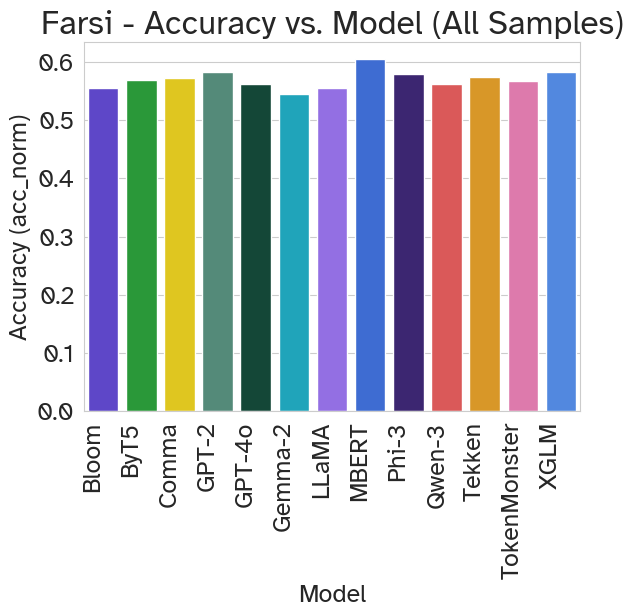

In [119]:
### Here using ALL SAMPLES

accuracies_by_model = all_samples.pivot_table(
    index="model_name", values=METRIC, aggfunc="mean"
)
accuracies_by_model
sns.barplot(accuracies_by_model, x="model_name", y=METRIC, palette=MODEL_TO_COLOR)
plt.xticks(rotation=90, ha="right")
plt.xlabel("Model")
plt.ylabel(f"Accuracy ({METRIC})")
plt.title(f"{title_pattern}Accuracy vs. Model (All Samples)")

print(accuracies_by_model)

### Canonical vs. Pertuerbed

                           acc_norm
model_name   is_canonical          
Bloom        False         0.544118
             True          0.750000
ByT5         False         0.557353
             True          0.775000
Comma        False         0.560294
             True          0.775000
GPT-2        False         0.570588
             True          0.775000
GPT-4o       False         0.551471
             True          0.750000
Gemma-2      False         0.532353
             True          0.750000
LLaMA        False         0.542647
             True          0.775000
MBERT        False         0.592647
             True          0.800000
Phi-3        False         0.564706
             True          0.825000
Qwen-3       False         0.544118
             True          0.850000
Tekken       False         0.557353
             True          0.850000
TokenMonster False         0.558824
             True          0.700000
XGLM         False         0.569118
             True          0

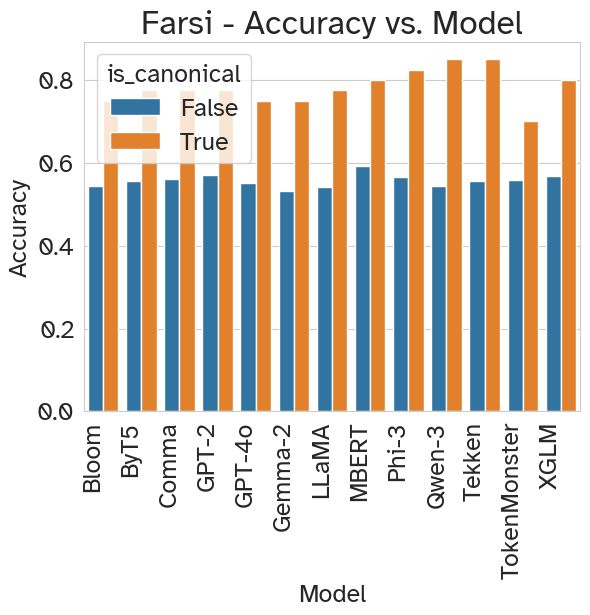

In [120]:
accuracies_by_model = all_samples.pivot_table(
    index=["model_name", "is_canonical"], values=METRIC, aggfunc="mean"
)
accuracies_by_model
sns.barplot(accuracies_by_model, x="model_name", y=METRIC, hue="is_canonical")
plt.xticks(rotation=90, ha="right")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title(f"{title_pattern}Accuracy vs. Model")

print(accuracies_by_model)

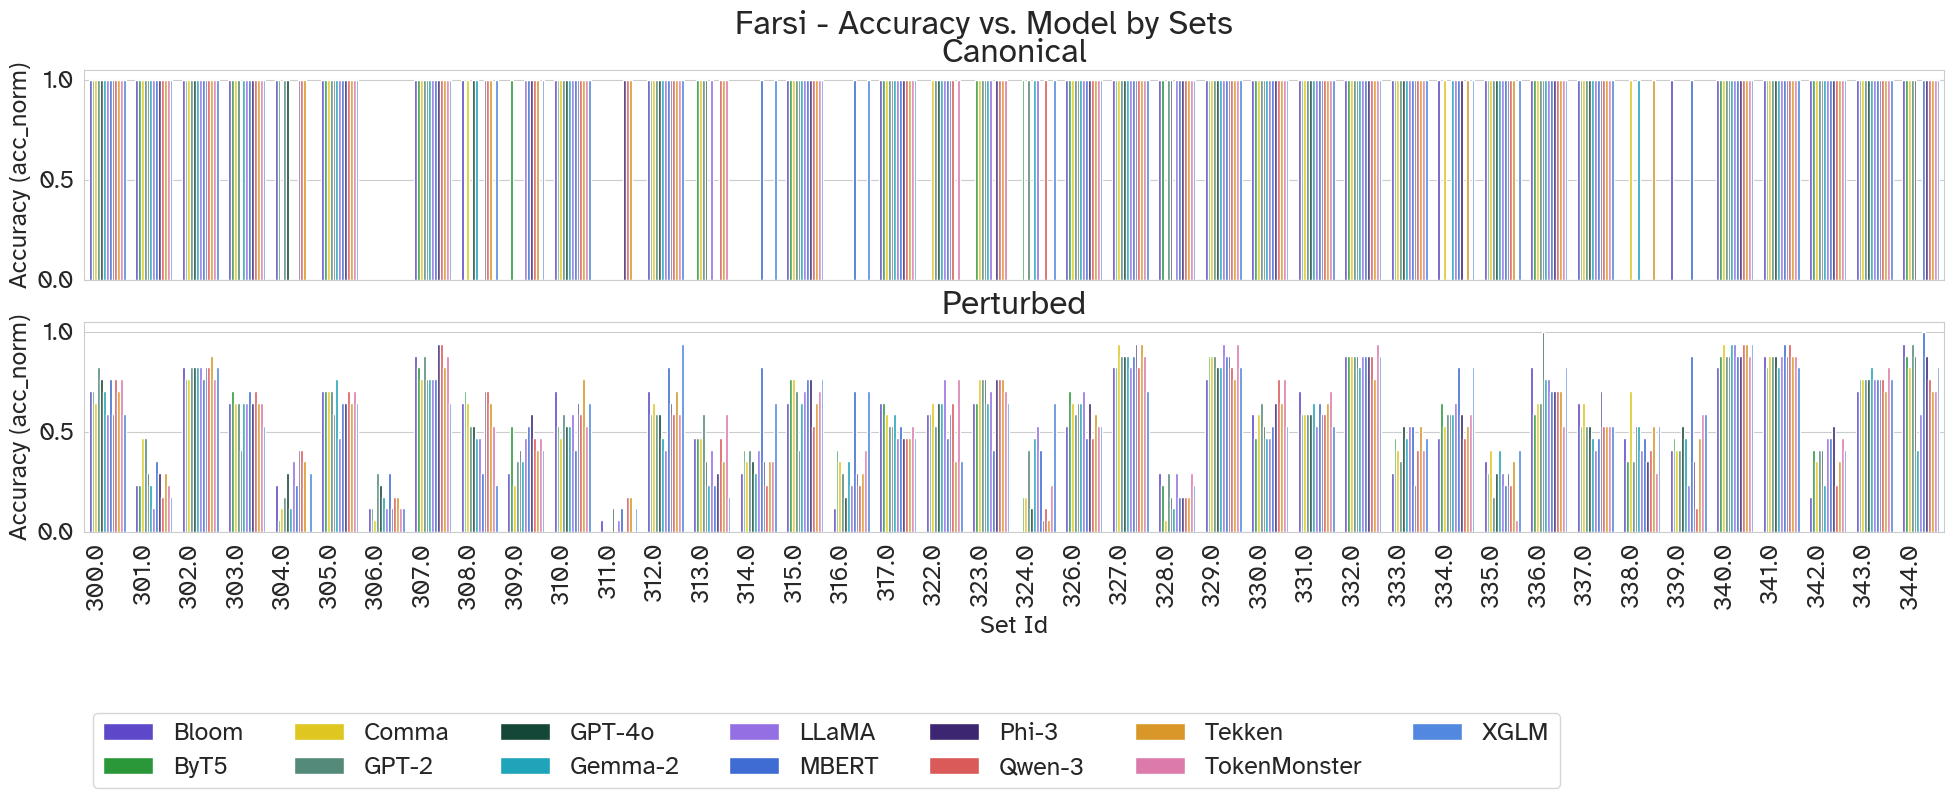

      set_id    model_name  is_canonical  acc_norm
0      300.0         Bloom         False  0.705882
1      300.0         Bloom          True  1.000000
2      300.0          ByT5         False  0.705882
3      300.0          ByT5          True  1.000000
4      300.0         Comma         False  0.647059
...      ...           ...           ...       ...
1035   344.0        Tekken          True  1.000000
1036   344.0  TokenMonster         False  0.705882
1037   344.0  TokenMonster          True  1.000000
1038   344.0          XGLM         False  0.823529
1039   344.0          XGLM          True  1.000000

[1040 rows x 4 columns]


In [121]:
accuracies_by_model = all_samples.copy()
accuracies_by_model = all_samples.pivot_table(
    index=["set_id", "model_name", "is_canonical"], values=METRIC, aggfunc="mean"
).reset_index()
fig, axs = plt.subplots(2, 1, figsize=(24, 6), sharex=True)
axs = axs.flat
sns.barplot(
    accuracies_by_model[accuracies_by_model["is_canonical"]],
    x="set_id",
    y=METRIC,
    hue="model_name",
    palette=MODEL_TO_COLOR,
    ax=axs[0],
    legend=False,
)
axs[0].set_title("Canonical")
axs[1].set_title("Perturbed")

sns.barplot(
    accuracies_by_model[~accuracies_by_model["is_canonical"]],
    x="set_id",
    y=METRIC,
    hue="model_name",
    palette=MODEL_TO_COLOR,
    ax=axs[1],
    legend=True,
)
axs[1].legend(bbox_to_anchor=(0.8, -0.8, 0, 0), ncol=7)
plt.xticks(rotation=90, ha="right")
plt.xlabel("Set Id")
axs[0].set_ylabel(f"Accuracy ({METRIC})")
axs[1].set_ylabel(f"Accuracy ({METRIC})")
fig.suptitle(f"{title_pattern}Accuracy vs. Model by Sets")
plt.show()
print(accuracies_by_model)

                                                           acc_norm
model_name subcategories                                           
Bloom      Arabic Keyboard for Farsi                       0.461538
           Cannonical                                      0.769231
           Code/language/script switching                  0.820513
           Colloquial                                      0.615385
           Diacritics presence/absence                     0.512821
...                                                             ...
XGLM       Dialects                                        0.558333
           Equivalent expressions                          0.750000
           Keyboard proximity errors                       0.600000
           Romanization                                    0.325000
           Word Spacing/Zero-width characters/Extra Space  0.650000

[130 rows x 1 columns]


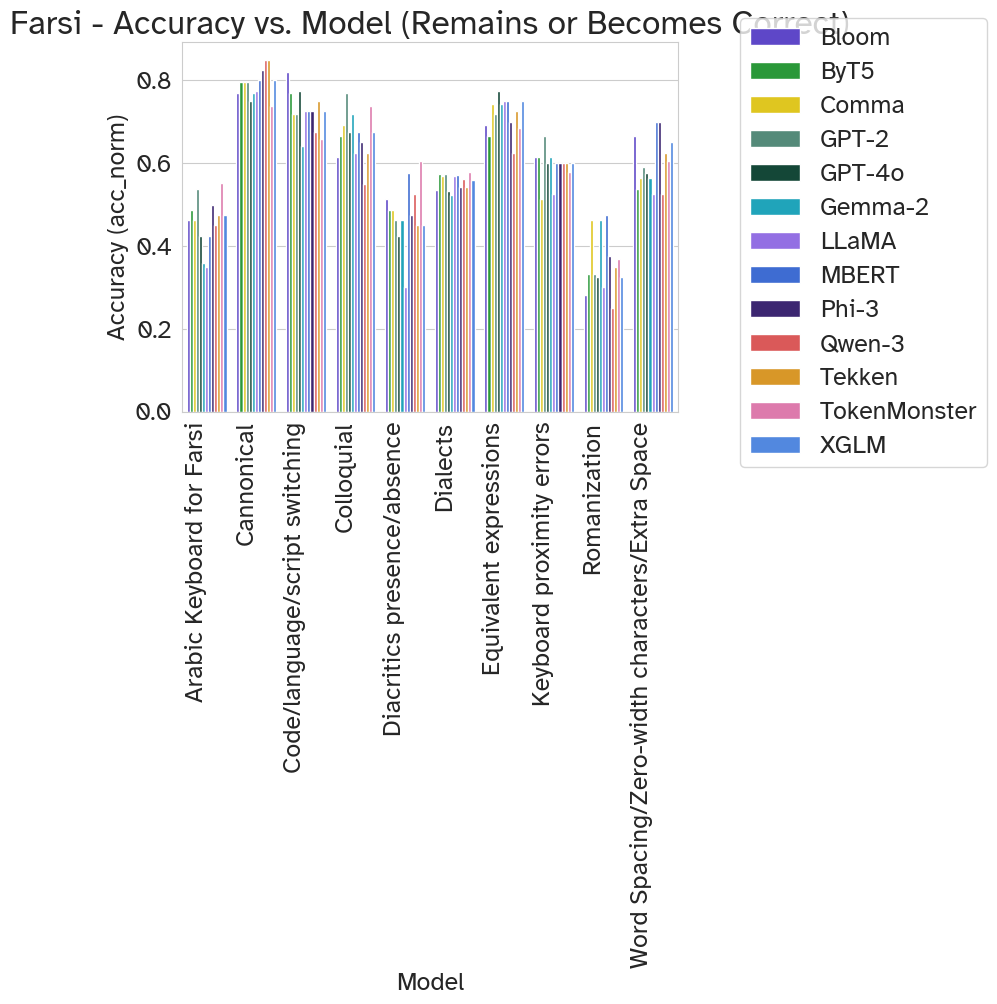

In [122]:
from xarch_tokenizers.logging.plot_utils import MODEL_TO_COLOR

accuracies_by_model = samples.pivot_table(
    index=["model_name", "subcategories"], values=METRIC, aggfunc="mean"
)
sns.barplot(
    accuracies_by_model,
    x="subcategories",
    y=METRIC,
    hue="model_name",
    # palette="viridis",
    palette=MODEL_TO_COLOR,
)
plt.xticks(rotation=90, ha="right")
plt.xlabel("Model")
plt.ylabel(f"Accuracy ({METRIC})")
plt.title(f"{title_pattern}Accuracy vs. Model {suffix}")
plt.legend(bbox_to_anchor=(1.1, 1.1))

print(accuracies_by_model)

                                                           acc_norm
model_name subcategories                                           
Bloom      Arabic Keyboard for Farsi                       0.450000
           Cannonical                                      0.750000
           Code/language/script switching                  0.800000
           Colloquial                                      0.600000
           Diacritics presence/absence                     0.500000
...                                                             ...
XGLM       Dialects                                        0.558333
           Equivalent expressions                          0.750000
           Keyboard proximity errors                       0.600000
           Romanization                                    0.325000
           Word Spacing/Zero-width characters/Extra Space  0.650000

[130 rows x 1 columns]


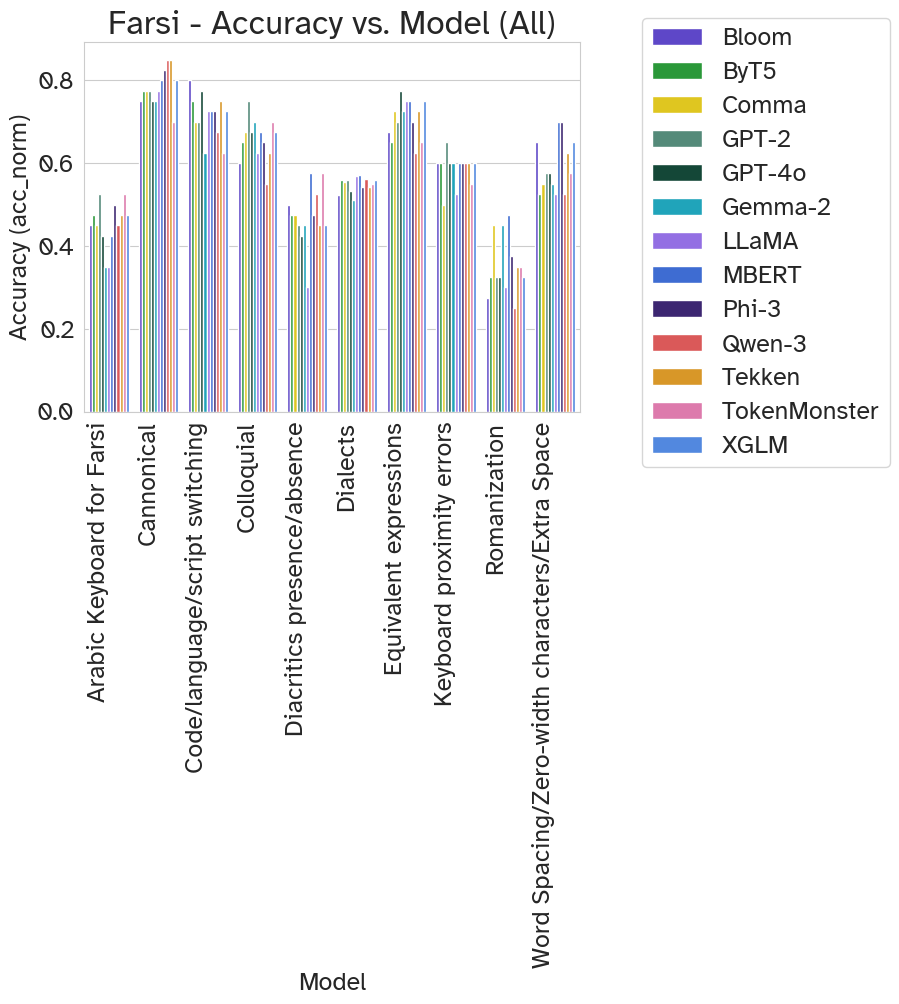

In [123]:
from xarch_tokenizers.logging.plot_utils import MODEL_TO_COLOR

accuracies_by_model = all_samples.pivot_table(
    index=["model_name", "subcategories"], values=METRIC, aggfunc="mean"
)
accuracies_by_model
sns.barplot(
    accuracies_by_model,
    x="subcategories",
    y=METRIC,
    hue="model_name",
    # palette="viridis",
    palette=MODEL_TO_COLOR,
)
plt.xticks(rotation=90, ha="right")
plt.xlabel("Model")
plt.ylabel(f"Accuracy ({METRIC})")
plt.title(f"{title_pattern}Accuracy vs. Model (All)")
plt.legend(bbox_to_anchor=(1.1, 1.1))

print(accuracies_by_model)

Plotting farsi_tokenizer_robustness_completion_arabic_keyboard_for_farsi into position 1
Plotting farsi_tokenizer_robustness_completion_word_spacing_zero-width_characters_extra_space into position 2
Plotting farsi_tokenizer_robustness_completion_diacritics_presence_absence into position 3
Plotting farsi_tokenizer_robustness_completion_keyboard_proximity_errors into position 4
Plotting farsi_tokenizer_robustness_completion_equivalent_expressions into position 5
Plotting farsi_tokenizer_robustness_completion_romanization into position 6
Plotting farsi_tokenizer_robustness_completion_dialects into position 7
Plotting farsi_tokenizer_robustness_completion_colloquial into position 8


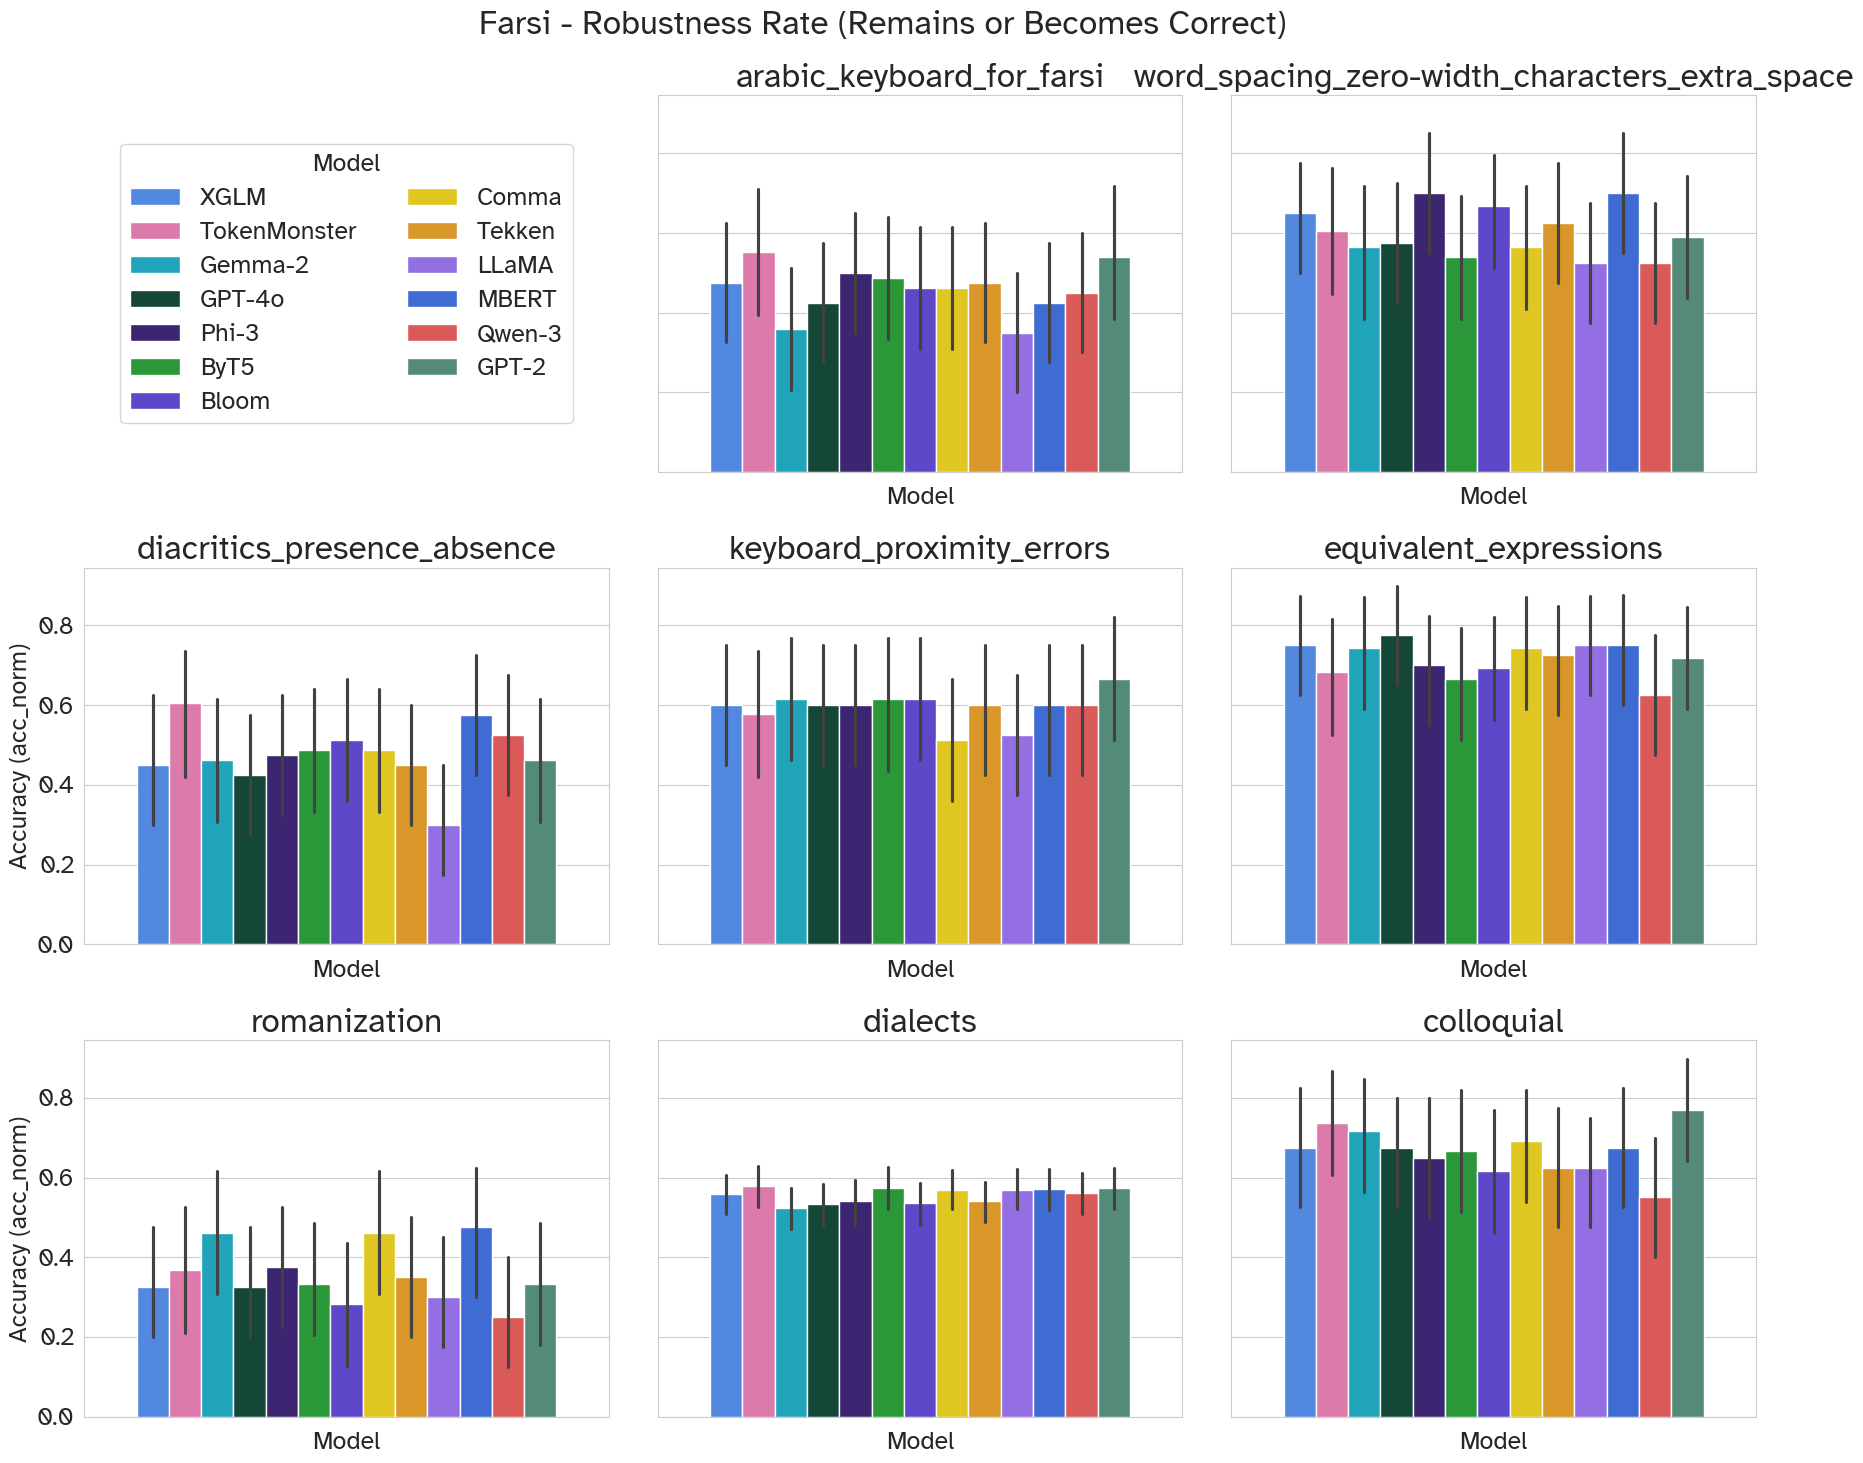

Plotting farsi_tokenizer_robustness_completion_code_language_script_switching into position 0


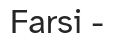

                                                           acc_norm
model_name subcategories                                           
Bloom      Arabic Keyboard for Farsi                       0.450000
           Cannonical                                      0.750000
           Code/language/script switching                  0.800000
           Colloquial                                      0.600000
           Diacritics presence/absence                     0.500000
...                                                             ...
XGLM       Dialects                                        0.558333
           Equivalent expressions                          0.750000
           Keyboard proximity errors                       0.600000
           Romanization                                    0.325000
           Word Spacing/Zero-width characters/Extra Space  0.650000

[130 rows x 1 columns]


In [124]:
nrows, ncols = 3, 3
fig, axs = get_new_fig(
    nrows=nrows, ncols=ncols, title=f"{title_pattern}Robustness Rate {suffix}"
)
tasks = samples["task"].unique()
tasks = tasks[1:]
for i, task in enumerate(tasks, 1):
    if i % len(axs) == 0:
        fig, axs = get_new_fig(nrows=nrows, ncols=ncols, title=title_pattern)
    print(f"Plotting {task} into position {i % len(axs)}")
    filter_ = samples["task"] == task
    tmp = samples[filter_]
    ax = axs[i % len(axs)]
    sns.barplot(
        tmp, hue="model_name", y=METRIC, palette=MODEL_TO_COLOR, ax=ax, legend=i == 1
    )
    ax.set_xlabel("Model")
    ax.set_ylabel(f"Accuracy ({METRIC})")
    title = (
        task.replace("tokenizer_robustness_completion_", "")
        .replace(f"{code_pattern.replace('*', '')}_", "")
        .replace("farsi_", "")
    )
    ax.set_title(title)
    # Check if we need to show the current figure
    is_last_task = i == len(tasks) + 1
    is_end_of_6 = (i + 1) % (nrows * ncols) == 0
    if i == 1:
        # Add legend to the first subplot of current figure
        handles, labels = axs[1].get_legend_handles_labels()
        axs[0].clear()
        axs[0].axis("off")
        axs[0].legend(handles, labels, title="Model", loc="center", ncol=2)
        axs[1].legend().set_visible(False)
    if is_last_task or is_end_of_6:
        # Hide any unused subplots in the current figure
        if is_last_task:
            print(i)
            num_plots_in_current_fig = (i % ncols * nrows) + 1
            for j in range(num_plots_in_current_fig, ncols * nrows):
                axs[j].set_visible(False)

        # Show the current figure
        plt.tight_layout()
        plt.show()
# Hide any unused subplots if there are fewer than 6 tasks
for j in range(len(tasks) % ncols * nrows, ncols * nrows):
    axs[j].set_visible(False)

# Adjust layout to prevent overlap
plt.tight_layout()

plt.show()

print(accuracies_by_model)

In [179]:
samples["subcategories"].value_counts()

subcategories
ASCII                         252
LaTeX                         252
Turkish                       252
Decorative Unicode            252
Farsi                         252
Spelled out                   252
Chinese                       252
Italian                       252
Turkish, Numerical formats     12
Name: count, dtype: int64